# Generador Académico RAG — Notebook integrador
**TP Integrador de Ciencia de Datos · UTN FRLP 2026 · Grupo 14**

Sistema de IA generativa que, alimentado por una base vectorial con el **historial académico
real** del grupo + el **plan de estudios** de la carrera, genera *artefactos académicos
personalizados* (planes de cursada, informes, cartas de pasantía, recomendaciones,
diagnóstico grupal, simulaciones). No responde preguntas: **sintetiza documentos nuevos**
anclados en datos privados que el modelo no conoce.

### Por qué es generativo y no un SQL
Un SQL te dice *qué* materias podés cursar (lookup). Esto te dice *qué conviene y por qué*,
redactado, con tono controlable, cruzando notas + correlativas + rendimiento. La salida es
texto nuevo sintetizado, no un campo de una tabla.

### Pipeline (lo construimos nosotros, no es NotebookLM)
```
PDFs ──pdfplumber──▶ documentos (estructurado + no estructurado)
     ──MiniLM──▶ embeddings ──▶ Chroma (base vectorial)
     ──retrieval top-k──▶ contexto ──▶ qwen2.5 (Ollama) ──▶ artefacto
```
Local, offline, privado. Si Ollama está apagado, la parte RAG funciona igual (recupera el
contexto) y la generación se completa al encender el modelo.

## 0 · Setup
Todo el código vive en `src/`. Cada módulo tiene self-checks; acá los orquestamos.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd() / "src"))  # importar los módulos del proyecto

import analisis, documents, extract, figuras, generar, ingest, rag, evaluar
from IPython.display import Image, display

print("Ollama:", "ENCENDIDO" if rag.ollama_disponible() else "apagado (modo solo-retrieval)")

Ollama: ENCENDIDO


## 1 · Extracción de los PDFs
`extract.pdf_to_text` usa **pdfplumber**. La fuente son estados académicos reales, exports de
notas de exámenes y el plan de estudios 2023 (correlatividades + equivalencias).

In [2]:
raw = documents.RAW_DIR
print("PDFs disponibles:", [p.name for p in sorted(raw.glob("*.pdf"))])
texto = extract.pdf_to_text(raw / "Plan-Sistemas-2023.pdf")
print(f"\nPlan 2023: {len(texto)} caracteres. Primeras líneas:\n")
print("\n".join(texto.splitlines()[:8]))

PDFs disponibles: ['Estado-Academico-Bauti.pdf', 'Estado-Academico-Lauti.pdf', 'Estado-Academico-Mora.pdf', 'Estado-Academico-Santi.pdf', 'Estado-Academico-Simon.pdf', 'Estado-Academico-Tomi.pdf', 'Notas-Bauti.pdf', 'Notas-Lauti.pdf', 'Notas-Mora.pdf', 'Notas-Santi.pdf', 'Notas-Simon.pdf', 'Notas-Tomi.pdf', 'Plan-Sistemas-2008.pdf', 'Plan-Sistemas-2023.pdf']



Plan 2023: 13208 caracteres. Primeras líneas:

“Las “Las Malvinas son argentinas”
Ministerio de Educación
Universidad Tecnológica Nacional
PABLO A. HUEL
Rectorado JEFE DE DEPARTAMENTO
APOYO AL CONSEJO SUPERIOR
RÉGIMEN DE CORRELATIVIDADES, EQUIVALENCIAS PARA MATERIAS
DE LA CARRERA INGENIERÍA EN SISTEMAS DE INFORMACIÓN


## 2 · Construcción del corpus
`documents.construir_corpus` fusiona lo **estructurado** (una entrada por materia con nota,
año, alumno) con lo **no estructurado** (chunks del plan) y parsea las **36 correlatividades**.
La clave de join entre estado y plan es el *nombre normalizado* (`normalizar`), porque los
códigos institucionales no coinciden entre documentos.

In [3]:
corpus = documents.construir_corpus()
print(f"Total documentos en el corpus: {len(corpus)}")
from collections import Counter
print("Por fuente:", dict(Counter(d["metadata"]["fuente"] for d in corpus)))

print("\nEjemplo (estado académico):")
ej = next(d for d in corpus if d["metadata"]["fuente"] == "estado_academico" and d["metadata"]["nota"] >= 0)
print(" texto:", ej["text"])
print(" metadata:", ej["metadata"])

Total documentos en el corpus: 418
Por fuente: {'estado_academico': 362, 'plan_estudios': 20, 'correlatividades': 36}

Ejemplo (estado académico):
 texto: Juan Cuenca, en la carrera Ingeniería en Sistemas de Información (Plan 2023), con la materia 'Algoritmos y Estructuras de Datos' (código 106, año 1 de la carrera): Aprobada con 8 (5 hs.) Tomo: 386 Folio: 2.
 metadata: {'fuente': 'estado_academico', 'alumno': 'Juan Cuenca', 'materia': 'Algoritmos y Estructuras de Datos', 'codigo': '106', 'anio': 1, 'nota': 8, 'estado': 'Aprobada con 8 (5 hs.) Tomo: 386 Folio: 2'}


## 3 · Embeddings + base vectorial Chroma
`ingest.reindexar` vectoriza el corpus con **all-MiniLM-L6-v2** (el embedding por defecto de
Chroma, local y offline) y lo persiste. Esta es la base que el modelo consultará.

In [4]:
n = ingest.reindexar()
print(f"Indexados {n} documentos en Chroma → {ingest.CHROMA_DIR}")

Indexados 418 documentos en Chroma → C:\Users\Simon Ocampo\OneDrive - UTN FRLP\Facultad\Ingenieria en Sistemas\Materias\5to\Ciencia de Datos\Practica\TP Grupal\generador-academico-rag\data\chroma


## 4 · Retrieval
Dos modos de recuperación:
- **Semántico** (`ingest.buscar`): similitud de embeddings, para preguntas en lenguaje natural.
- **Determinístico** (`ingest.obtener`): por metadata, para grounding exacto (las materias
  aprobadas de un alumno, las correlatividades). Es lo que ancla a los generadores.

In [5]:
print("### Búsqueda semántica: '¿qué necesito para cursar Ciencia de Datos?'")
for r in ingest.buscar("¿qué necesito para cursar Ciencia de Datos?", k=3):
    print(f"  [{r['distancia']:.3f}] ({r['metadata']['fuente']}) {r['text'][:90]}")

print("\n### Grounding determinístico: materias aprobadas de un alumno (por metadata)")
aprobadas = ingest.obtener({"$and": [{"fuente": "estado_academico"}, {"alumno": "Simón Ocampo"}]})
aprobadas = [d for d in aprobadas if d["metadata"]["nota"] >= 0]
print(f"  {len(aprobadas)} materias con nota. Ejemplos:", [d["metadata"]["materia"] for d in aprobadas[:5]])

### Búsqueda semántica: '¿qué necesito para cursar Ciencia de Datos?'


  [0.517] (correlatividades) En el plan 2023 de Ingeniería en Sistemas de Información, 'Ciencia de Datos' es la materia
  [0.674] (correlatividades) En el plan 2023 de Ingeniería en Sistemas de Información, 'Redes de Datos' es la materia N
  [0.687] (correlatividades) En el plan 2023 de Ingeniería en Sistemas de Información, 'Comunicación de Datos' es la ma

### Grounding determinístico: materias aprobadas de un alumno (por metadata)
  35 materias con nota. Ejemplos: ['Algoritmos y Estructuras de Datos', 'Análisis Matemático I', 'Arquitectura de Computadoras', 'Física I', 'Inglés I']


## 5 · EDA + visualización
`analisis` arma un DataFrame de notas **reales de los 6 integrantes del grupo**, fusionando el
estado académico de cada uno con su export de exámenes. Cada registro es `(alumno, materia, año,
nota, área)`; las áreas temáticas mapean las 36 obligatorias del plan en 6 grupos.

In [6]:
real = analisis.tabla_real()
print(f"Registros reales: {len(real)} | alumnos: {real['alumno'].nunique()}")
display(analisis.promedio_por_alumno(real).to_frame("promedio"))

grupo = analisis.tabla_grupo()  # los 6 integrantes, todos con datos reales
perfil = analisis.perfil_por_area(grupo)
print("\nPerfil por área (nota media) — los 6 integrantes:")
display(perfil)

Registros reales: 199 | alumnos: 6


,promedio
alumno,
Mora Gentil,8.70
Lautaro Aubert,8.48
Simón Ocampo,8.40
Santiago Natalichio,8.15
Juan Cuenca,8.09
Tomas Martin,7.91



Perfil por área (nota media) — los 6 integrantes:


area,Datos e Inteligencia,Idiomas,Infraestructura y Redes,Matemática y Física,Otras,Programación,Sistemas y Gestión
alumno,,,,,,,
Juan Cuenca,7.5,10.0,8.0,8.38,7.80,7.25,8.14
Lautaro Aubert,7.0,9.5,8.0,9.00,8.20,8.50,8.29
Mora Gentil,8.5,9.0,8.2,8.75,8.80,8.75,8.86
Santiago Natalichio,7.5,9.5,7.4,8.25,8.20,7.50,8.71
Simón Ocampo,9.0,9.0,8.0,8.62,8.43,8.00,8.29
Tomas Martin,8.5,6.5,7.4,7.88,8.17,7.75,8.43


Generando figuras en C:\Users\Simon Ocampo\OneDrive - UTN FRLP\Facultad\Ingenieria en Sistemas\Materias\5to\Ciencia de Datos\Practica\TP Grupal\generador-academico-rag\figs


  [ok] notas_distribucion.png


  [ok] avance_anual.png


  [ok] radar_areas.png


  [ok] clustering_perfiles.png


  [ok] materias_embeddings.png


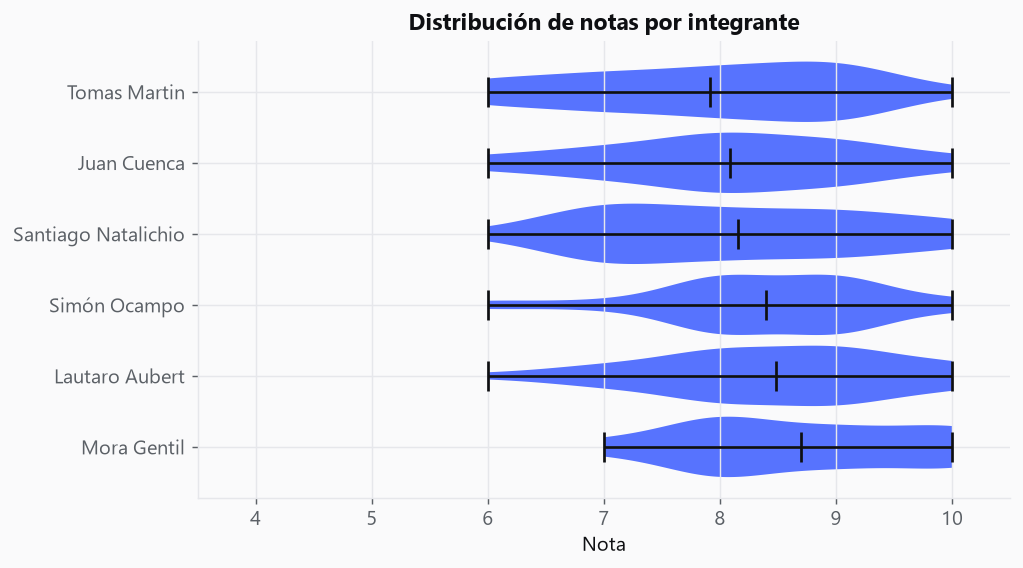

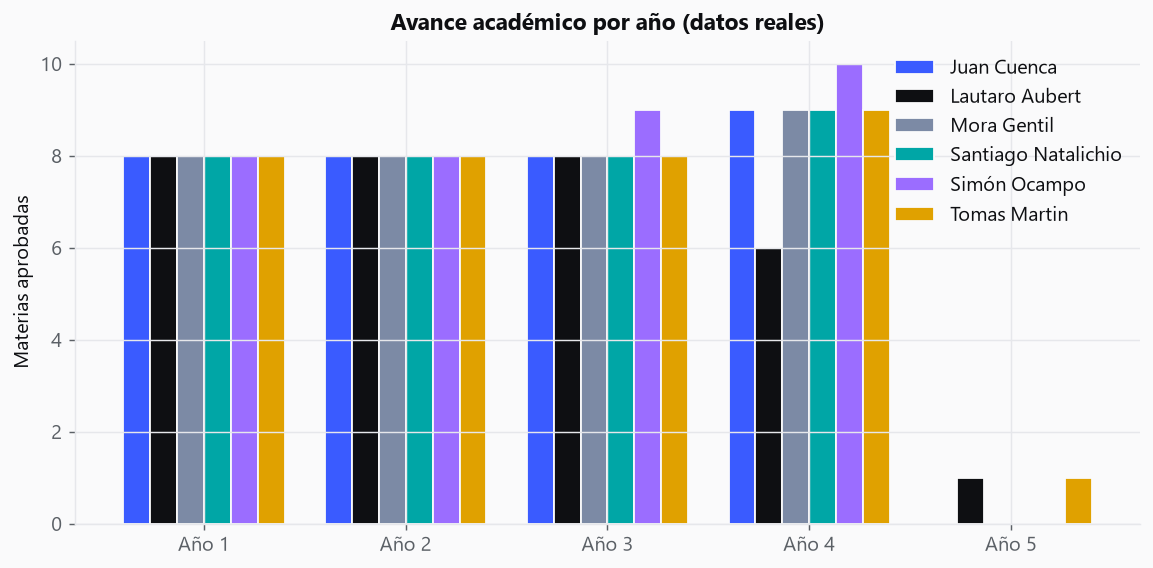

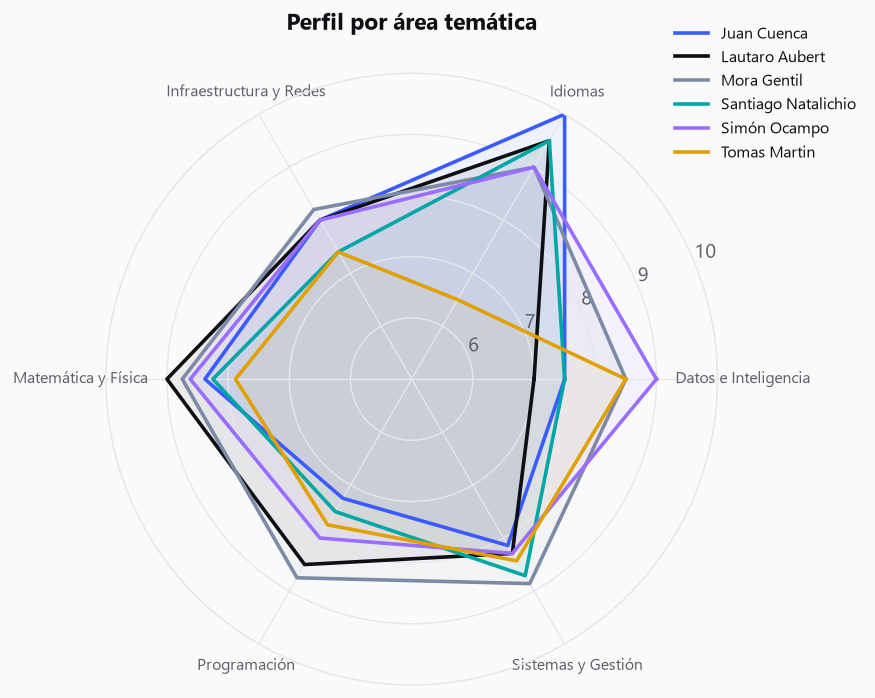

In [7]:
figuras.generar_todo()  # regenera los PNG con estilo Graphite & Cobalt
for png in ["notas_distribucion.png", "avance_anual.png", "radar_areas.png"]:
    display(Image(filename=str(figuras.FIGS / png)))

## 6 · Clustering de perfiles
KMeans sobre el perfil por área (estandarizado), proyectado a 2D con PCA. Y, aparte, las 36
obligatorias proyectadas con **t-SNE de sus embeddings**: las materias de la misma área caen
juntas, lo que valida que el espacio semántico capturó la estructura del plan.

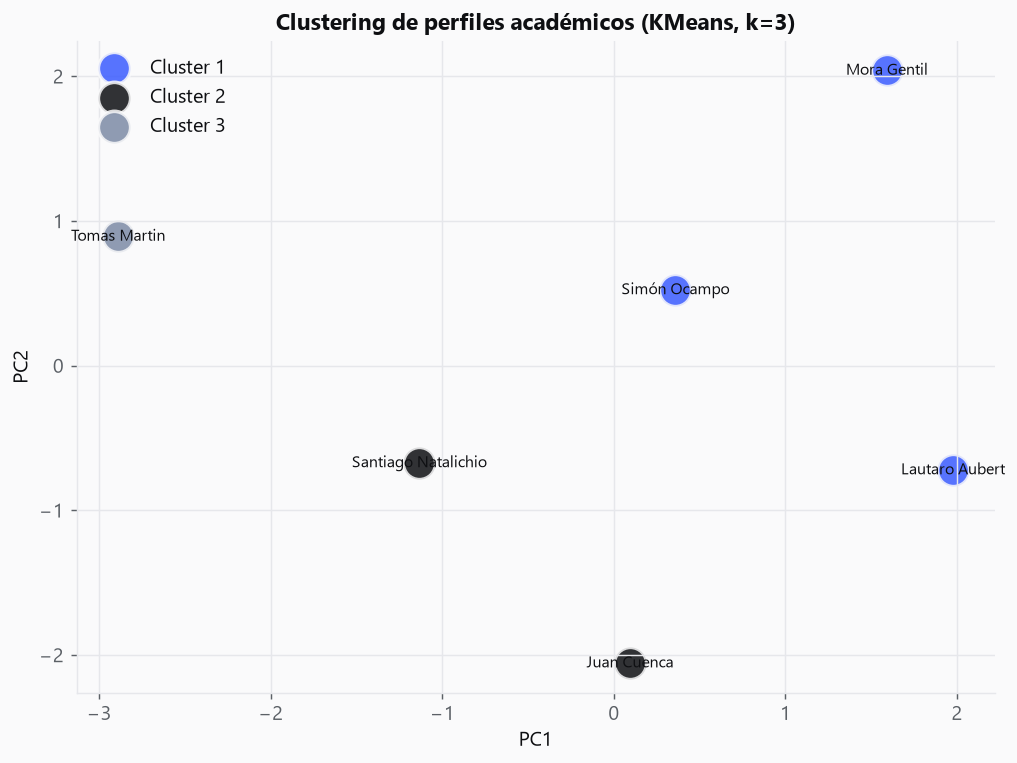

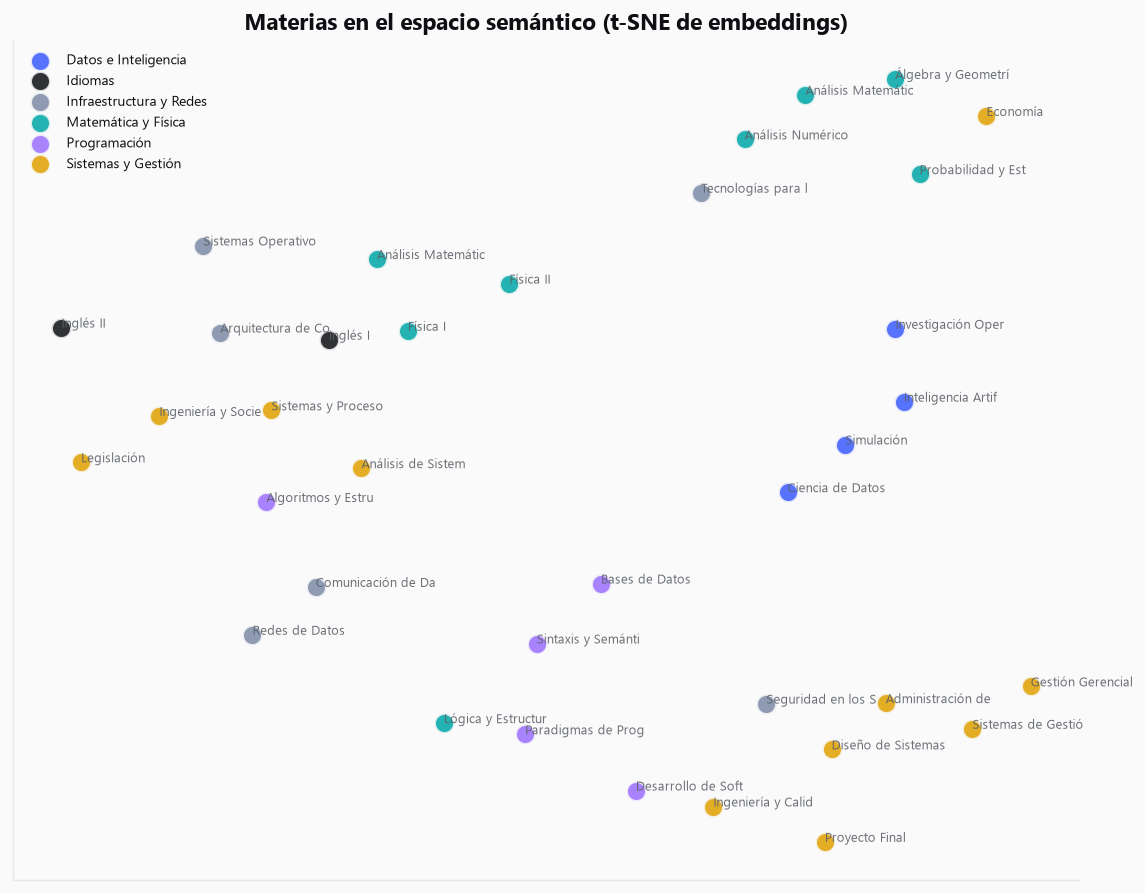

In [8]:
display(Image(filename=str(figuras.FIGS / "clustering_perfiles.png")))
display(Image(filename=str(figuras.FIGS / "materias_embeddings.png")))

## 7 · Generación de artefactos con tono
Cada generador ancla la salida en el contexto recuperado (grounding) y pasa **solo ese
contexto** al LLM. El **tono** (técnico / motivacional / honesto) cambia el registro sobre los
mismos datos: eso es lo que lo hace generativo y no un reporte fijo.

In [9]:
art = generar.plan_cursada("Simón Ocampo", tono="tecnico")
print("Artefacto:", art["artefacto"], "| fuente:", art["fuente"])
print(f"\nCONTEXTO recuperado ({len(art['contexto'])} chars), primeras líneas:")
print("\n".join(art["contexto"].splitlines()[:6]))

print("\n--- SALIDA ---")
if art["salida"]:
    print(art["salida"])
else:
    print("(Ollama apagado) El contexto de arriba ya es la parte RAG. Encendé el modelo para la generación.")

Artefacto: plan_cursada | fuente: ollama

CONTEXTO recuperado (3881 chars), primeras líneas:
MATERIAS APROBADAS por Simón Ocampo:
- Algoritmos y Estructuras de Datos (nota 8, año 1)
- Análisis Matemático I (nota 9, año 1)
- Arquitectura de Computadoras (nota 8, año 1)
- Física I (nota 9, año 1)
- Inglés I (nota 9, año 1)

--- SALIDA ---
Plan de Cursada del Cuatrimestre 2023-2024 para Simón Ocampo

1. **Materias Aprobadas:**
   - Algoritmos y Estructuras de Datos (8, 1º año)
   - Análisis Matemático I (9, 1º año)
   - Arquitectura de Computadoras (8, 1º año)
   - Física I (9, 1º año)
   - Inglés I (9, 1º año)
   - Lógica y Estructuras Discretas (10, 1º año)

2. **Materias Correlativas para Cursar:**
   - Paradigmas de Programación (8, 2º año)
   - Sistemas Operativos (6, 2º año)
   - Análisis Numérico (9, 3º año)
   - Bases de Datos (9, 3º año)

3. **Materias Correlativas para Rendir:**
   - Lógica y Estructuras Discretas (10, 2º año)
   - Algoritmos y Estructuras de Datos (8, 1º año)



## 8 · Evaluación — grounding con/sin RAG (demo estrella)
Medimos el anclaje de la salida con **dos métricas complementarias**:
- **Grounding léxico**: fracción de los tokens informativos de la salida (nombres de materias,
  notas) que aparecen literalmente en el contexto real. Explicable, pero penaliza paráfrasis.
- **Grounding semántico**: promedio del máximo coseno entre cada oración de la salida y los
  fragmentos del contexto (mismos embeddings MiniLM). Reconoce la paráfrasis legítima.

El mismo pedido CON RAG (contexto real) vs SIN RAG (sin contexto) hace medible el aporte del
conocimiento privado: sin él, el modelo no puede anclar y ambos groundings caen.

In [10]:
contexto = ("- Simón Ocampo aprobó Bases de Datos con 9 en el año 3.\n"
            "- Simón Ocampo aprobó Análisis Matemático I con 9 en el año 1.")
anclada = "Simón rindió Bases de Datos con 9 y Análisis Matemático con 9, muy buen desempeño."
inventada = "Recomiendo cursar Astrofísica Cuántica y Derecho Romano el próximo cuatrimestre."
print("léxico   — anclada:", evaluar.grounding_score(anclada, contexto),
      "| inventada:", evaluar.grounding_score(inventada, contexto))
print("semántico — anclada:", evaluar.grounding_semantico(anclada, contexto),
      "| inventada:", evaluar.grounding_semantico(inventada, contexto))

if rag.ollama_disponible():
    cmp = evaluar.comparar_con_sin_rag(generar.plan_cursada, alumno="Simón Ocampo")
    print(f"\n[plan_cursada] grounding léxico   CON RAG = {cmp['con_rag']['grounding']}"
          f"  ·  SIN RAG = {cmp['sin_rag']['grounding']}")
    print(f"[plan_cursada] grounding semántico CON RAG = {cmp['con_rag']['grounding_sem']}"
          f"  ·  SIN RAG = {cmp['sin_rag']['grounding_sem']}")
else:
    print("\n(Ollama apagado) Encendé el modelo para la comparación con/sin RAG sobre un artefacto real.")

léxico   — anclada: 1.0 | inventada: 0.0


semántico — anclada: 0.686 | inventada: 0.338



[plan_cursada] grounding léxico   CON RAG = 0.711  ·  SIN RAG = 0.286
[plan_cursada] grounding semántico CON RAG = 0.779  ·  SIN RAG = 0.588


## 9 · Conclusiones
- Construimos el **pipeline RAG completo** (extracción, corpus mixto, embeddings, Chroma,
  retrieval, generación) en vez de usar una caja negra.
- El sistema **genera** artefactos personalizados con tono, no responde preguntas: cada salida
  es contenido nuevo anclado en datos privados.
- La **demo con/sin RAG** y el **grounding** hacen medible y visible el aporte del conocimiento
  privado: sin él, el modelo no puede anclar y la calidad cae.
- Pipeline de Ciencia de Datos completo: EDA, visualización, clustering y evaluación.

La web app (`iniciar.bat`) permite probar todo esto en vivo, con la consola de contexto y el
medidor de grounding en tiempo real.